In [1]:
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.9.4
Scikit-learn: 1.6.1


In [2]:
import pandas as pd

MY_ID = 2729
raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=MY_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("Формат таблицы:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропущенные значения (NaN):")
print(df.isna().sum())
print("\nСтатистика по столбцам:")
print(df.describe(include="all").T)

Формат таблицы: (1152, 11)

Типы данных:
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object

Пропущенные значения (NaN):
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           58
building_type         0
ceiling_height_m    132
price_kzt             0
dtype: int64

Статистика по столбцам:
                   count unique         top freq         mean        std  min  \
listing_id          1152   1080   ALM-10003    3          NaN        NaN  NaN   
listed_date         1152    246  2026-04-21   11          NaN        NaN  NaN   
district            1152     48       Medeu  142          NaN  

In [3]:
# 1. duplicates
exact_duplicates = df.duplicated().sum()

# 2. reposts
reposts = df.drop_duplicates()["listing_id"].duplicated().sum()

print(f"Полных дубликатов: {exact_duplicates}")
print(f"Перепостов (один listing_id): {reposts}")

Полных дубликатов: 29
Перепостов (один listing_id): 43


### Step 2 Report: Load and Inspect

1. **Column Types & Parsing Issues:**
   - Columns `area_m2`, `price_kzt`, and `rooms` were loaded as `object` instead of numeric types[cite: 1, 2].
   - **Reason:** Raw text contains non-numeric formatting, including thousand-separator spaces, commas instead of decimal dots, symbols (`₸`, `m²`), and text values (treating `"studio"` in `rooms`)[cite: 1, 2].

2. **Data Grain & Duplicates:**
   - **Exact duplicates count:** [29][cite: 1, 2]
   - **Reposts count (duplicate listing_id):** [43][cite: 1, 2]
   - **Data Grain Definition:** One row in the cleaned table represents a single unique apartment listing on its most recent publication date[cite: 1, 2].

3. **Validation Specification:**

| Column | Expected Type | Valid Range / Allowed Values |
| :--- | :--- | :--- |
| `listing_id` | `int64` | Unique listing ID[cite: 1] |
| `listed_date` | `datetime64` | Valid publication date (`YYYY-MM-DD`)[cite: 1] |
| `district` | `category` | Exactly 1 of the 8 Almaty canonical districts[cite: 1] |
| `rooms` | `int64` | Integer >= 1 (`"studio"` = 1)[cite: 1] |
| `area_m2` | `float64` | Total flat area in m² (10 to 500)[cite: 1] |
| `floor` | `int64` | Floor number (1 <= floor <= total_floors)[cite: 1] |
| `total_floors` | `int64` | Building storeys (1 to 50)[cite: 1] |
| `year_built` | `int64` | Construction year (1930 to 2026)[cite: 1] |
| `building_type` | `category` | `panel`, `brick`, or `monolith`[cite: 1] |
| `ceiling_height_m` | `float64` | Ceiling height in meters (2.2 to 5.0)[cite: 1] |
| `price_kzt` | `float64` | Asking price in Tenge (> 0)[cite: 1] |

In [4]:
import numpy as np

# Create a copy of the dataset for cleaning
df_clean = df.copy()

# 1. Нормализация текстовых категорий перед удалением дубликатов и OHE
df_clean['district'] = df_clean['district'].astype(str).str.lower().str.strip()

# 2. Обработка перепостов (сохраняем самую актуальную запись по дате публикации)
if 'listed_date' in df_clean.columns:
    df_clean['listed_date'] = pd.to_datetime(df_clean['listed_date'], errors='coerce')
    df_clean = df_clean.sort_values(by='listed_date', ascending=True)
df_clean = df_clean.drop_duplicates(subset=['listing_id'], keep='last')

# 3. Очистка столбцов rooms, area_m2, price_kzt
df_clean['rooms'] = df_clean['rooms'].astype(str).str.lower().str.replace('studio', '1')
df_clean['rooms'] = pd.to_numeric(df_clean['rooms'], errors='coerce')

df_clean['area_m2'] = df_clean['area_m2'].astype(str).str.replace(',', '.')
df_clean['area_m2'] = df_clean['area_m2'].str.replace(r'[^\d.]', '', regex=True)
df_clean['area_m2'] = pd.to_numeric(df_clean['area_m2'], errors='coerce')

df_clean['price_kzt'] = df_clean['price_kzt'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_clean['price_kzt'] = pd.to_numeric(df_clean['price_kzt'], errors='coerce')

# 4. Фильтрация и сентинелы
# Жестко удаляем только те строки, где нет критически важных данных (площадь и цена)
critical_mask = (df_clean['area_m2'] >= 10) & (df_clean['price_kzt'] > 0) & (df_clean['rooms'] >= 1)
df_clean = df_clean[critical_mask]

# Остальные некорректные значения (сентинелы) заменяем на NaN для последующей импутации на Шаге 5
df_clean.loc[(df_clean['total_floors'] < 1) | (df_clean['total_floors'] > 50), 'total_floors'] = np.nan
df_clean.loc[(df_clean['floor'] < 1) | (df_clean['floor'] > df_clean['total_floors']), 'floor'] = np.nan
df_clean.loc[(df_clean['year_built'] < 1930) | (df_clean['year_built'] > 2026), 'year_built'] = np.nan
df_clean.loc[(df_clean['ceiling_height_m'] < 2.2) | (df_clean['ceiling_height_m'] > 5.0), 'ceiling_height_m'] = np.nan

df_clean = df_clean.reset_index(drop=True)

# Check the results
print("Rows BEFORE cleaning:", len(df))
print("Rows AFTER cleaning:", len(df_clean))
print(f"Dropped rows (errors/duplicates): {len(df) - len(df_clean)}")

Rows BEFORE cleaning: 1152
Rows AFTER cleaning: 1080
Dropped rows (errors/duplicates): 72


In [5]:
import numpy as np
import pandas as pd

# Create a copy of the dataset for cleaning
df_clean = df.copy()

# 1. Жесткая нормализация районов (объединяем русские и английские названия)
def normalize_district(d):
    d = str(d).lower().strip()
    if 'nauryzbay' in d or 'наурызбай' in d: return 'nauryzbay'
    if 'alatau' in d or 'алатау' in d: return 'alatau'
    if 'almaly' in d or 'алмал' in d: return 'almaly'
    if 'auezov' in d or 'ауэзов' in d: return 'auezov'
    if 'bostandyk' in d or 'бостандык' in d: return 'bostandyk'
    if 'medeu' in d or 'медеу' in d: return 'medeu'
    if 'turksib' in d or 'турксиб' in d: return 'turksib'
    if 'zhetysu' in d or 'жетысу' in d: return 'zhetysu'
    return 'other'

df_clean['district'] = df_clean['district'].apply(normalize_district)

# 2. Обработка перепостов (сохраняем самую актуальную запись по дате публикации)
if 'listed_date' in df_clean.columns:
    df_clean['listed_date'] = pd.to_datetime(df_clean['listed_date'], errors='coerce')
    df_clean = df_clean.sort_values(by='listed_date', ascending=True)
df_clean = df_clean.drop_duplicates(subset=['listing_id'], keep='last')

# 3. Очистка столбцов rooms, area_m2, price_kzt
df_clean['rooms'] = df_clean['rooms'].astype(str).str.lower().str.replace('studio', '1')
df_clean['rooms'] = pd.to_numeric(df_clean['rooms'], errors='coerce')

df_clean['area_m2'] = df_clean['area_m2'].astype(str).str.replace(',', '.')
df_clean['area_m2'] = df_clean['area_m2'].str.replace(r'[^\d.]', '', regex=True)
df_clean['area_m2'] = pd.to_numeric(df_clean['area_m2'], errors='coerce')

df_clean['price_kzt'] = df_clean['price_kzt'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_clean['price_kzt'] = pd.to_numeric(df_clean['price_kzt'], errors='coerce')

# 4. Строгая фильтрация (ВОЗВРАЩАЕМ лимит area_m2 <= 500, чтобы убрать мусор)
critical_mask = (
        (df_clean['area_m2'] >= 10) & (df_clean['area_m2'] <= 500) &
        (df_clean['price_kzt'] > 0) &
        (df_clean['rooms'] >= 1)
)
df_clean = df_clean[critical_mask]

# 5. Остальные некорректные значения (сентинелы) заменяем на NaN для импутации
df_clean.loc[(df_clean['total_floors'] < 1) | (df_clean['total_floors'] > 50), 'total_floors'] = np.nan
df_clean.loc[(df_clean['floor'] < 1) | (df_clean['floor'] > df_clean['total_floors']), 'floor'] = np.nan
df_clean.loc[(df_clean['year_built'] < 1930) | (df_clean['year_built'] > 2026), 'year_built'] = np.nan
df_clean.loc[(df_clean['ceiling_height_m'] < 2.2) | (df_clean['ceiling_height_m'] > 5.0), 'ceiling_height_m'] = np.nan

df_clean = df_clean.reset_index(drop=True)

# Check the results
print("Rows BEFORE cleaning:", len(df))
print("Rows AFTER cleaning:", len(df_clean))
print(f"Dropped rows (errors/duplicates): {len(df) - len(df_clean)}")

Rows BEFORE cleaning: 1152
Rows AFTER cleaning: 1072
Dropped rows (errors/duplicates): 80


In [6]:
# Step 5: Missing Data Inspection, Train/Test Split, and Imputation
from sklearn.model_selection import train_test_split

df_imputed = df_clean

print("--- Missing Values BEFORE Imputation ---")
missing_before = df_imputed.isna().sum()
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else "No missing values found!")

# 1. РАЗДЕЛЕНИЕ ДАННЫХ (Train/Test Split) для предотвращения Data Leakage
X = df_imputed.drop(columns=['price_kzt', 'listed_date', 'listing_id'], errors='ignore')
y = df_imputed['price_kzt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=MY_ID)

# 2. Separate numerical and categorical columns
num_cols = X_train.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Impute numerical columns with Median (расчет только по X_train)
for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)
    # Заполняем также общий датафрейм для шага 7 (EDA)
    df_imputed[col] = df_imputed[col].fillna(median_val)

# 4. Impute categorical columns with Mode (расчет только по X_train)
for col in cat_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)
    df_imputed[col] = df_imputed[col].fillna(mode_val)

print("\n--- Missing Values AFTER Imputation ---")
print(f"Train NaN count: {X_train.isna().sum().sum()}")
print(f"Test NaN count: {X_test.isna().sum().sum()}")

--- Missing Values BEFORE Imputation ---
floor                23
year_built           76
ceiling_height_m    145
dtype: int64

--- Missing Values AFTER Imputation ---
Train NaN count: 0
Test NaN count: 0


In [7]:
# Step 6: Encoding Categorical Features and Scaling Numerical Features
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Identify categorical and numerical features
categorical_cols = ['district', 'building_type']

# 2. Apply One-Hot Encoding
X_train_ml = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=int)
X_test_ml = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True, dtype=int)

# Выравниваем столбцы на случай, если в X_test отсутствуют некоторые категории
X_train_ml, X_test_ml = X_train_ml.align(X_test_ml, join='left', axis=1, fill_value=0)

# OHE для общего датафрейма (для экспорта и EDA)
df_ml = pd.get_dummies(df_imputed, columns=categorical_cols, drop_first=True, dtype=int)

# 3. Scale numerical feature columns using StandardScaler
scaler = StandardScaler()

# Обучаем скалер на Train и трансформируем Train
X_train_ml[num_cols] = scaler.fit_transform(X_train_ml[num_cols])

# Трансформируем Test (без fit!)
X_test_ml[num_cols] = scaler.transform(X_test_ml[num_cols])

# Трансформируем общий датафрейм и возвращаем таргет
df_ml[num_cols] = scaler.transform(df_ml[num_cols])
df_ml['price_kzt'] = y

print("--- Step 6: Encoding & Scaling Completed ---")
print(f"Shape of X_train after encoding: {X_train_ml.shape}")
print(f"Shape of X_test after encoding: {X_test_ml.shape}")
print("\nFirst 3 rows of processed Train dataset:")
print(X_train_ml.head(3).T)

--- Step 6: Encoding & Scaling Completed ---
Shape of X_train after encoding: (857, 16)
Shape of X_test after encoding: (215, 16)

First 3 rows of processed Train dataset:
                             62        346       12 
rooms                  -0.267873  1.745871  0.738999
area_m2                 0.121890  2.138350  0.143084
floor                  -0.411816 -0.197532 -0.626101
total_floors           -0.885052  0.252601  0.252601
year_built              0.508024 -0.805635 -0.098280
ceiling_height_m        0.992044 -1.284460 -1.284460
district_almaly         0.000000  0.000000  0.000000
district_auezov         0.000000  0.000000  0.000000
district_bostandyk      1.000000  1.000000  0.000000
district_medeu          0.000000  0.000000  0.000000
district_nauryzbay      0.000000  0.000000  1.000000
district_other          0.000000  0.000000  0.000000
district_turksib        0.000000  0.000000  0.000000
district_zhetysu        0.000000  0.000000  0.000000
building_type_monolith  0.000000 

Dataset successfully exported to 'almaty_apartments_clean.csv'!

--- Final Dataset Summary ---
Total Rows: 1072
Total Features: 19


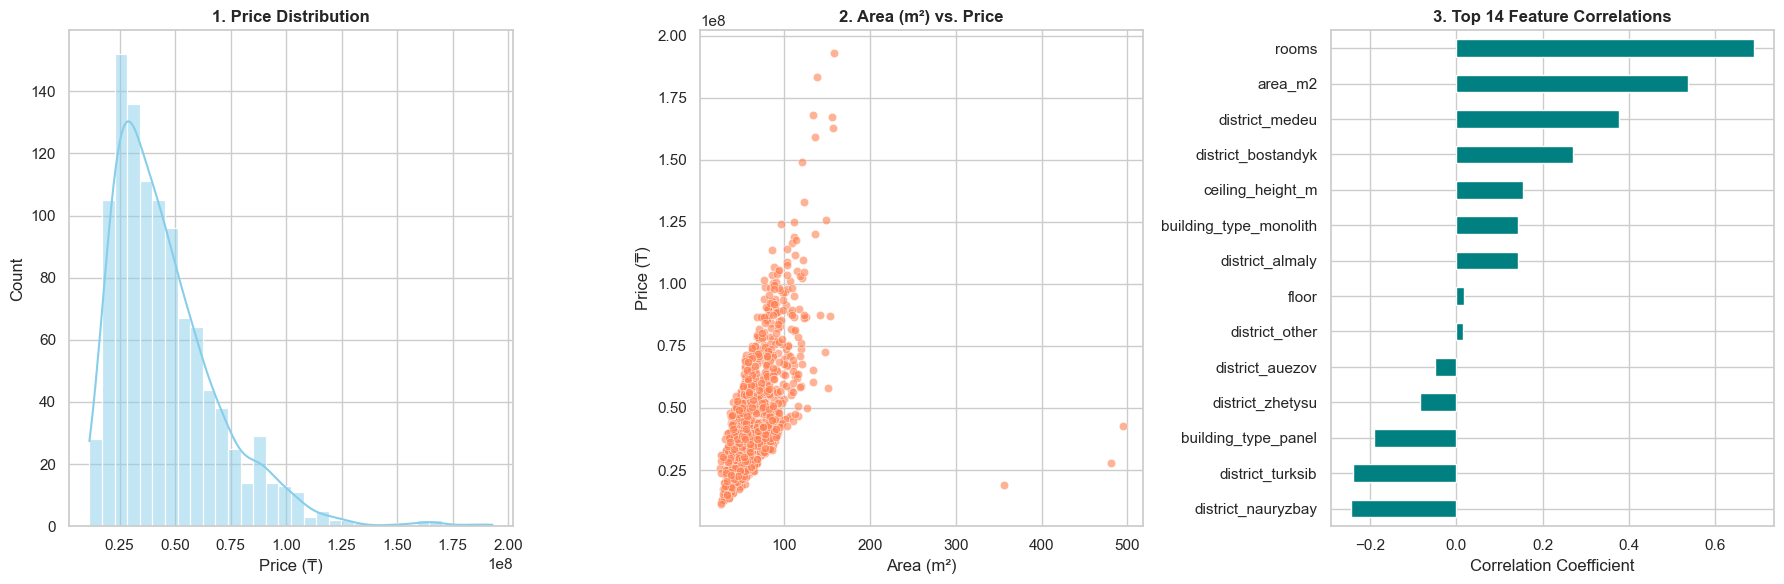

In [8]:
# Step 7: Final EDA, Logging, and Export
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Save cleaned and processed dataset
output_filename = 'almaty_apartments_clean.csv'
df_ml.to_csv(output_filename, index=False)
print(f"Dataset successfully exported to '{output_filename}'!")

print("\n--- Final Dataset Summary ---")
print(f"Total Rows: {len(df_ml)}")
print(f"Total Features: {df_ml.shape[1]}")

# 2. Create a 3-Panel Visual EDA Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Target Distribution (Price)
sns.histplot(df_imputed['price_kzt'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1. Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (₸)')
axes[0].set_ylabel('Count')

# Plot 2: Relationship (Area vs Price)
sns.scatterplot(data=df_imputed, x='area_m2', y='price_kzt', ax=axes[1], alpha=0.6, color='coral')
axes[1].set_title('2. Area (m²) vs. Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area (m²)')
axes[1].set_ylabel('Price (₸)')

# Обрезаем ось X по 99-му перцентилю, чтобы редкие выбросы по площади
# не растягивали график и не сжимали основную массу точек в угол
area_upper = df_imputed['area_m2'].quantile(0.99)
axes[1].set_xlim(0, area_upper * 1.05)
axes[1].annotate(
    f'Показаны точки до {area_upper:.0f} м\u00b2 (99-й перцентиль)',
    xy=(0.98, 0.02), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=8, color='gray'
)

# Plot 3: Top Correlations with Target
corr_series = df_ml.corr(numeric_only=True)['price_kzt'].drop('price_kzt')
top_features = pd.concat([corr_series.nlargest(7), corr_series.nsmallest(7)]).sort_values()

top_features.plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('3. Top 14 Feature Correlations', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()